## Estudiante: Darío Fernando García Ortega, 1004534662

# Lab 3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?


In [1]:
import numpy as np
import matplotlib.pyplot as plt

Converge en 1231 iteraciones (max diff = 0.0)


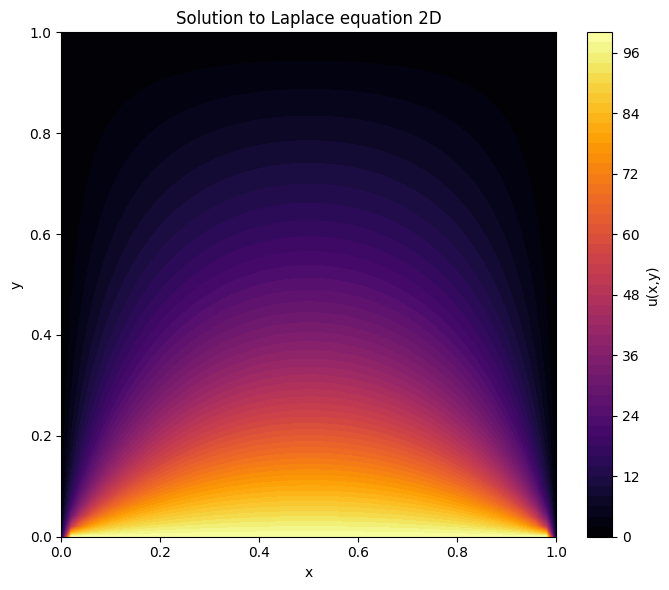

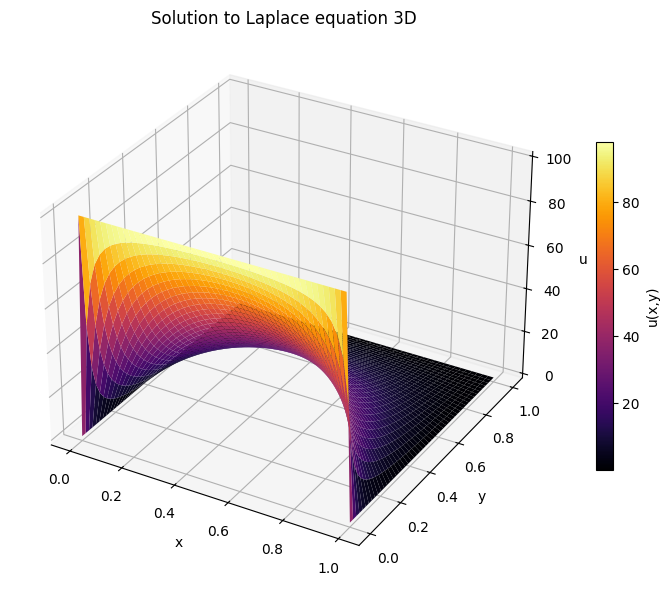

In [41]:
## parámetros
L = 1
N = 50
V0 = 100
tol = 1e-7
max_iter = 10000

## malla de puntos
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
dx = x[1] - x[0]
dy = y[1] - y[0]

# u[i, j] -> i para x, j para y
u = np.zeros((N, N)) # estableciendo los valores iniciales de cada punto de la malla

##  condiciones de frontera
# u(x, 0) = V0
u[:, 0] = V0
# u(0, y) = 0
u[0, :] = 0
# u(L, y) = 0
u[-1, :] = 0
# u(x, L) = 0
u[:, -1] = 0

# rellenando las esquinas inferiores
#u[0, 0] = V0
#u[-1, 0] = V0

## función solución con gauss-seidel implementado
omega = 1.5  # factor 1<omega<2 que facilita la convergencia

for it in range(max_iter):
    u_old = u.copy()
    for i in range(1, N-1):
        for j in range(1, N-1):
            u_new = 0.25 * (u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1])
            u[i, j] = (1 - omega) * u[i, j] + omega * u_new # actualizando únicamente los puntos interiores

    diff = np.max(np.abs(u - u_old))
    if diff < tol:
        print(f"Converge en {it+1} iteraciones (max diff = {np.round(diff,4)})")
        break
else:
    print(f"No converge en {max_iter} iteraciones (max diff = {np.round(diff,4)})")

# grid para las gráficas
X, Y = np.meshgrid(x, y, indexing='ij')


fig1, ax1 = plt.subplots(figsize=(7, 6))
c = ax1.contourf(X, Y, u, levels=50, cmap='inferno')
fig1.colorbar(c, ax=ax1, label='u(x,y)')
ax1.set_title('Solution to Laplace equation 2D')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
plt.tight_layout()

fig2 = plt.figure(figsize=(8, 6))
ax2 = fig2.add_subplot(111, projection='3d')
surf = ax2.plot_surface(X, Y, u, cmap='inferno', edgecolor='none')
fig2.colorbar(surf, ax=ax2, shrink=0.6, label='u(x,y)')
ax2.set_title('Solution to Laplace equation 3D')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u')
plt.tight_layout()

# Sln. analítica:

$$
u(x,y) = \frac{400}{\pi}\sum_{n=1,3,5,\ldots}^{\infty} \frac{1}{n}\sin\!\left(\frac{n\pi x}{L}\right)\frac{\sinh\!\left(\dfrac{n\pi (L-y)}{L}\right)}{\sinh\!\left(\dfrac{n\pi L}{L}\right)}
$$

u minimo = 0.0000, u maximo = 100.0085


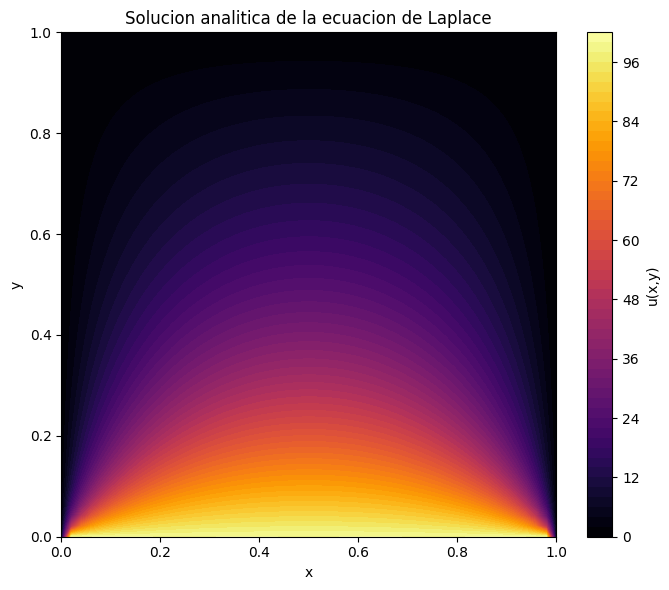

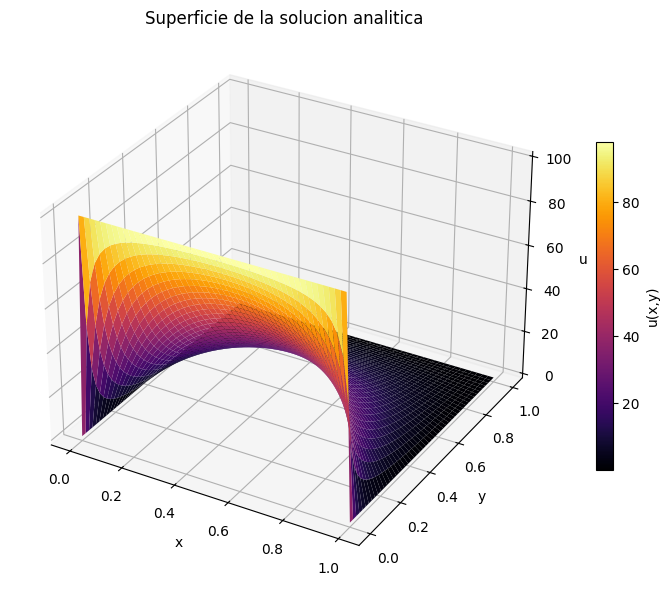

In [42]:
def u_analitica(x, y, L=1.0, n_terms=200):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    n = np.arange(1, 2 * n_terms, 2)              # n = 1, 3, 5, ...
    n = n.reshape((-1,) + (1,) * x.ndim)

    a = n * np.pi * (L - y) / L
    b = n * np.pi
    ratio = np.exp(a - b) * (1 - np.exp(-2 * a)) / (1 - np.exp(-2 * b)) ## combinación de exponenciales es equivalente

    terminos = (1.0 / n) * np.sin(n * np.pi * x / L) * ratio
    return (400.0 / np.pi) * terminos.sum(axis=0)

# Evaluar en una malla
L = 1.0
n_terms = 10000

x = np.linspace(0, L, 50)
y = np.linspace(0, L, 50)
X, Y = np.meshgrid(x, y, indexing='ij')

# Evitar y=0 exacto para no dividir en el limite (no es necesario aqui,
# pero se deja un pequeno margen para evaluar el borde con seguridad)
U = u_analitica(X, Y, L=L, n_terms=n_terms)

print(f"u minimo = {U.min():.4f}, u maximo = {U.max():.4f}")

fig1, ax1 = plt.subplots(figsize=(7, 6))
c = ax1.contourf(X, Y, U, levels=50, cmap='inferno')
fig1.colorbar(c, ax=ax1, label='u(x,y)')
ax1.set_title('Solucion analitica de la ecuacion de Laplace')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
plt.tight_layout()

fig2 = plt.figure(figsize=(8, 6))
ax2 = fig2.add_subplot(111, projection='3d')
surf = ax2.plot_surface(X, Y, U, cmap='inferno', edgecolor='none')
fig2.colorbar(surf, ax=ax2, shrink=0.6, label='u(x,y)')
ax2.set_title('Superficie de la solucion analitica')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u')
plt.tight_layout()

In [45]:
np.mean(abs(u-U)) # francamente no sé cómo medir la diferencia de manera representativa entre ambas superficies,
# un valor de tolerancia 1e-4 no parece conseguirse en la generalidad del mapa al restar ambos incluso al disminuir
# grandemente el valor de tolerancia del primero y aumentar el número de términos del segundo. tol = 1e-7; terminos = 10000

np.float64(0.011668678592080968)

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3**

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

Convergio en 205 iteraciones (diff max = 7.46e-06)
u minimo = -100.00, u maximo = 100.00


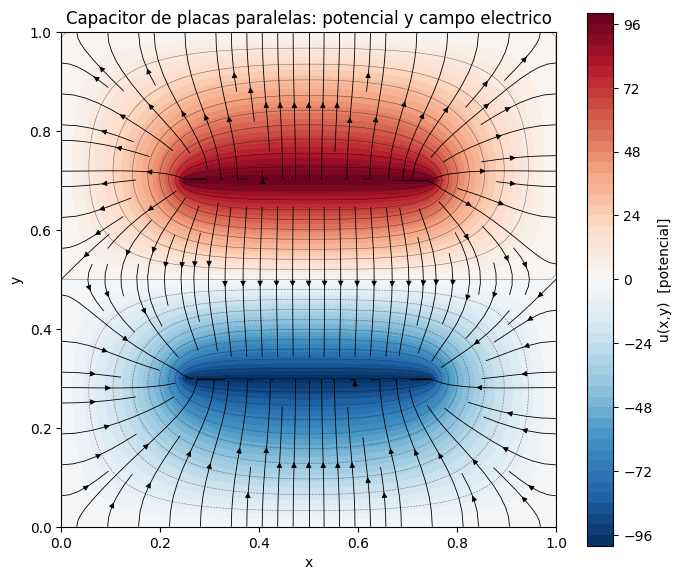

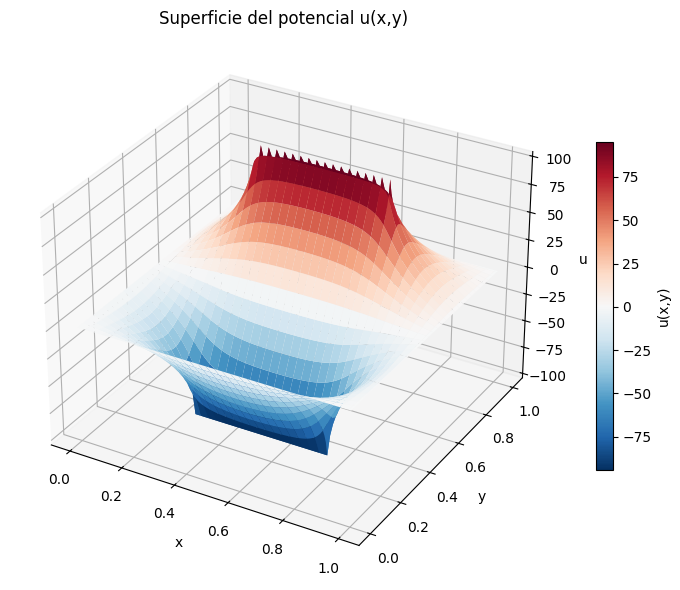

In [2]:
## malla y parámetros
L = 1.0
N = 101                    # puntos por lado (N impar para tener fila/col central exacta)
V0 = 100
tol = 1e-5
max_iter = 20000
omega = 1.9                # factor 1<omega<2

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
dx = x[1] - x[0]

u = np.zeros((N, N))       # u[i, j]: i para x, j para y

Dd = 0.5 # ancho de cada placa como fraccion de L (coordenada i horizontal)
i_ini = int((0.5 - Dd / 2) * (N - 1))
i_fin = int((0.5 + Dd / 2) * (N - 1))

j_placa_sup = int(0.7 * (N - 1))   # placa superior (y = 0.7*L)  -> +V0
j_placa_inf = int(0.3 * (N - 1))   # placa inferior (y = 0.3*L)  -> -V0

u[i_ini:i_fin + 1, j_placa_sup] = +V0
u[i_ini:i_fin + 1, j_placa_inf] = -V0

# Mascara de puntos fijos (borde de la caja + placas): no se actualizan
fijo = np.zeros((N, N), dtype=bool)
fijo[0, :] = True   #lateral izquierdo
fijo[-1, :] = True  #lateral derecho
fijo[:, 0] = True   #banda inferior
fijo[:, -1] = True  #banda superior
fijo[i_ini:i_fin + 1, j_placa_sup] = True # placa superior
fijo[i_ini:i_fin + 1, j_placa_inf] = True # placa inferior

# Iteracion Gauss-Seidel
for it in range(max_iter):
    u_old = u.copy()

    for i in range(1, N - 1):
        for j in range(1, N - 1):
            if fijo[i, j]:
                continue
            u_new = 0.25 * (u[i + 1, j] + u[i - 1, j] + u[i, j + 1] + u[i, j - 1])
            u[i, j] = (1 - omega) * u[i, j] + omega * u_new

    diff = np.max(np.abs(u - u_old))
    if diff < tol:
        print(f"Convergio en {it + 1} iteraciones (diff max = {diff:.2e})")
        break
else:
    print(f"No convergio en {max_iter} iteraciones (diff max = {diff:.2e})")


# E = -grad(u)

Ey, Ex = np.gradient(-u, dx, dx)   # np.gradient regresa d/d(eje0), d/d(eje1)
# u[i,j]: eje0 = x, eje1 = y  -> gradiente[0] = dU/dx, gradiente[1] = dU/dy
dUdx, dUdy = np.gradient(u, dx, dx)
Ex, Ey = -dUdx, -dUdy

X, Y = np.meshgrid(x, y, indexing='ij')

## mapa de potencial
fig1, ax1 = plt.subplots(figsize=(7, 6))
c = ax1.contourf(X, Y, u, levels=60, cmap='RdBu_r')
fig1.colorbar(c, ax=ax1, label='u(x,y)  [potencial]')
ax1.contour(X, Y, u, levels=20, colors='k', linewidths=0.4, alpha=0.5)

## campo E
ax1.streamplot(x, y, Ex.T, Ey.T, color='k', density=1.1, linewidth=0.6, arrowsize=0.8)

ax1.set_title('Capacitor de placas paralelas: potencial y campo electrico')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_aspect('equal')
plt.tight_layout()

## ## potencial en 3d
fig2 = plt.figure(figsize=(8, 6))
ax2 = fig2.add_subplot(111, projection='3d')
surf = ax2.plot_surface(X, Y, u, cmap='RdBu_r', edgecolor='none')
fig2.colorbar(surf, ax=ax2, shrink=0.6, label='u(x,y)')
ax2.set_title('Superficie del potencial u(x,y)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u')
plt.tight_layout()

print(f"u minimo = {u.min():.2f}, u maximo = {u.max():.2f}")